# REDES NEURONALES
## ¿Reincidirá una persona en libertad condicional?

Usamos la MISMA base que en los ejercicios de Árbol y Random Forest (`base_seguridad_reincidencia.csv`), para poder comparar los 3 métodos sobre exactamente los mismos datos.

**La secuencia es:**
1. Cargar y limpiar los datos
2. Separar en entrenamiento (80%) y prueba (20%)
3. Escalar las variables (CRÍTICO en redes neuronales)
4. Entrenar la red neuronal
5. Predecir sobre los datos de prueba
6. Construir matriz de confusión y evaluar el modelo
7. Revisar qué variables pesaron más
8. Visualizar la arquitectura de la red
9. Aplicar el modelo a registros nuevos


## PASO 0. Importar las librerías necesarias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier        # la red neuronal
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

%matplotlib inline

## PASO 1. Cargar la base de datos

**Nota:** ajusta la ruta del archivo CSV a donde tengas guardada tu base de datos en tu computadora.

In [3]:
datos = pd.read_csv(r"datos\base_seguridad_reincidencia.csv")
datos.head()

,edad,delito_previo,num_delitos_previos,meses_en_prision,empleo,apoyo_familiar,consumo_sustancias,nivel_educativo,supervision_post,reincidencia
0,56,Robo,1,28,No,Si,No,Universidad,Media,No
1,46,Violencia_familiar,2,25,Si,No,No,Secundaria,Baja,Si
2,32,Robo,0,45,No,Si,No,Preparatoria,Baja,No
3,60,Narcomenudeo,2,15,Si,No,No,Preparatoria,Baja,No
4,25,Violencia_familiar,1,30,No,Si,Si,Secundaria,Media,Si


In [4]:
# ¿Cuántas personas reincidieron?
datos["reincidencia"].value_counts()

reincidencia
No    620
Si    380
Name: count, dtype: int64

## PASO 2. Preparar las variables (X) y la variable objetivo (y)

### 2a. Variable objetivo (y)

In [5]:
le_objetivo = LabelEncoder()
y = le_objetivo.fit_transform(datos["reincidencia"])
# Categorías de la variable objetivo y su código numérico
dict(zip(le_objetivo.classes_, le_objetivo.transform(le_objetivo.classes_)))

{'No': np.int64(0), 'Si': np.int64(1)}

### 2b. Variables predictoras (X)

In [6]:
# Igual que en el árbol y Random Forest, convertimos las variables de
# texto a columnas dummy (0/1).
X = datos.drop(columns=["reincidencia"])
X = pd.get_dummies(X, columns=["delito_previo", "empleo", "apoyo_familiar",
                                "consumo_sustancias", "nivel_educativo",
                                "supervision_post"])
print(f"\nNúmero de variables predictoras después de codificar: {X.shape[1]}")


Número de variables predictoras después de codificar: 20


## PASO 3. Dividir en entrenamiento (80%) y prueba (20%)

Misma semilla (`random_state=3`) que en el árbol y Random Forest, para que los métodos se evalúen sobre el mismo conjunto de prueba.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=3,
    stratify=y
)
print(f"\nTamaño del conjunto de entrenamiento: {X_train.shape[0]} personas")
print(f"Tamaño del conjunto de prueba:        {X_test.shape[0]} personas")


Tamaño del conjunto de entrenamiento: 800 personas
Tamaño del conjunto de prueba:        200 personas


## PASO 4. Escalar las variables — paso crítico en redes neuronales

A diferencia del árbol y Random Forest (que no necesitan escalado porque solo comparan "mayor o menor que"), una red neuronal SÍ lo necesita: si una variable como `meses_en_prision` (rango 3-60) y otra como `empleo_Si` (rango 0-1) entran sin escalar, la red le da de entrada mucho más peso a la que tiene números más grandes, no porque sea más importante, sino solo por su escala numérica.

**IMPORTANTE:** igual que con `StandardScaler` en los ejercicios anteriores, ajustamos (`fit`) el escalador SOLO con datos de entrenamiento, y luego transformamos train y test con esos mismos parámetros — así no se filtra información del conjunto de prueba hacia el entrenamiento.

In [8]:
scaler = StandardScaler()
X_train_escalado = scaler.fit_transform(X_train)
X_test_escalado = scaler.transform(X_test)

print("\nEjemplo: primeras 3 filas de X_train ANTES de escalar (sin procesar):")
print(X_train.iloc[:3, :4])
print("\nEjemplo: primeras 3 filas DESPUÉS de escalar (media 0, desv. estándar 1):")
print(pd.DataFrame(X_train_escalado[:3, :4], columns=X.columns[:4]).round(3))


Ejemplo: primeras 3 filas de X_train ANTES de escalar (sin procesar):
     edad  num_delitos_previos  meses_en_prision  delito_previo_Fraude
26     39                    1                 8                 False
401    42                    2                15                 False
206    19                    1                21                 False

Ejemplo: primeras 3 filas DESPUÉS de escalar (media 0, desv. estándar 1):
    edad  num_delitos_previos  meses_en_prision  delito_previo_Fraude
0 -0.140               -0.389            -1.432                -0.336
1  0.083                0.421            -1.007                -0.336
2 -1.626               -0.389            -0.642                -0.336


## PASO 5. Crear y entrenar la red neuronal

In [9]:
modelo_red = MLPClassifier(
    hidden_layer_sizes=(10, 8, 5),   # 3 capas ocultas con 10, 8 y 5 neuronas
    activation="logistic",           # función de activación logistica,
    max_iter=100000,                 # máximo de iteraciones de entrenamiento
    random_state=3,                  # misma semilla que los demás modelos
    solver="adam"                    # algoritmo de optimización para retropropagación
)

# Entrenamos la red con los datos de entrenamiento YA ESCALADOS
modelo_red.fit(X_train_escalado, y_train)
print(f"\n✅ Red neuronal entrenada.")
print(f"   Iteraciones usadas: {modelo_red.n_iter_} de {modelo_red.max_iter} máximas")


✅ Red neuronal entrenada.
   Iteraciones usadas: 1081 de 100000 máximas


## PASO 6. Predecir sobre el conjunto de prueba

In [10]:
predicciones = modelo_red.predict(X_test_escalado)
probabilidades = modelo_red.predict_proba(X_test_escalado)[:, 1]  # prob. de "Sí"

print("\nPrimeras 10 predicciones (con su probabilidad de reincidencia):")
for i in range(10):
    clase_predicha = le_objetivo.classes_[predicciones[i]]
    clase_real = le_objetivo.classes_[y_test[i]]
    print(f"  Persona {i+1}: predicción = {clase_predicha} (prob={probabilidades[i]:.2f})  |  real = {clase_real}")


Primeras 10 predicciones (con su probabilidad de reincidencia):
  Persona 1: predicción = Si (prob=0.96)  |  real = Si
  Persona 2: predicción = Si (prob=0.97)  |  real = Si
  Persona 3: predicción = No (prob=0.01)  |  real = No
  Persona 4: predicción = No (prob=0.01)  |  real = No
  Persona 5: predicción = Si (prob=0.91)  |  real = No
  Persona 6: predicción = Si (prob=0.91)  |  real = Si
  Persona 7: predicción = No (prob=0.01)  |  real = No
  Persona 8: predicción = No (prob=0.03)  |  real = No
  Persona 9: predicción = Si (prob=0.97)  |  real = Si
  Persona 10: predicción = Si (prob=0.97)  |  real = Si


## PASO 7. Matriz de confusión y métricas de evaluación

In [11]:
print("\n" + "="*60)
print("MATRIZ DE CONFUSIÓN — Red Neuronal")
print("="*60)
matriz = confusion_matrix(y_test, predicciones)
matriz_df = pd.DataFrame(matriz, index=le_objetivo.classes_, columns=le_objetivo.classes_)
print("(filas = realidad, columnas = predicción)")
print(matriz_df)


MATRIZ DE CONFUSIÓN — Red Neuronal
(filas = realidad, columnas = predicción)
     No  Si
No  118   6
Si    8  68


In [12]:
exactitud = accuracy_score(y_test, predicciones)
print(f"\nExactitud general del modelo (accuracy): {exactitud:.3f}")
print("\nReporte de clasificación completo:")
print(classification_report(y_test, predicciones, target_names=le_objetivo.classes_))


Exactitud general del modelo (accuracy): 0.930

Reporte de clasificación completo:
              precision    recall  f1-score   support

          No       0.94      0.95      0.94       124
          Si       0.92      0.89      0.91        76

    accuracy                           0.93       200
   macro avg       0.93      0.92      0.93       200
weighted avg       0.93      0.93      0.93       200



**COMPARACIÓN: RANDOM FOREST vs REDES NEURONALES**

Recordemos los resultados de random forest (script anterior):
- Exactitud (accuracy): ~0.88
- Precisión clase "Sí": ~0.81

Compáralos con los resultados de este modelo (arriba).

## PASO 8. Importancia de variables — algoritmo de Olden

El algoritmo calcula la importancia de cada variable de entrada multiplicando, capa por capa, los pesos que la red aprendió en el camino desde esa variable hasta la salida final. Si el producto resulta positivo, esa variable empuja la predicción hacia "Sí reincide"; si es negativo, la empuja hacia "No reincide".

In [13]:
importancia_olden = modelo_red.coefs_[0]          # pesos: entrada -> capa 1
for matriz_pesos in modelo_red.coefs_[1:]:        # multiplicamos por cada
    importancia_olden = importancia_olden @ matriz_pesos  # capa siguiente
importancia_olden = importancia_olden.flatten()   # un valor por variable de entrada

serie_olden = pd.Series(importancia_olden, index=X.columns)
serie_olden_ordenada = serie_olden.reindex(serie_olden.abs().sort_values(ascending=False).index)

print("\nImportancia de cada variable según el algoritmo de Olden:")
print("(valores positivos empujan hacia 'Sí reincide'; negativos hacia 'No reincide')")
print(serie_olden_ordenada.head(10).round(1))


Importancia de cada variable según el algoritmo de Olden:
(valores positivos empujan hacia 'Sí reincide'; negativos hacia 'No reincide')
num_delitos_previos      1079.3
empleo_No                 709.3
empleo_Si                -659.8
edad                     -564.5
consumo_sustancias_No    -519.9
consumo_sustancias_Si     508.3
supervision_post_Alta    -468.0
apoyo_familiar_No         410.8
apoyo_familiar_Si        -401.8
supervision_post_Baja     381.2
dtype: float64


### Graficar las variables más importantes (top 10 por valor absoluto)

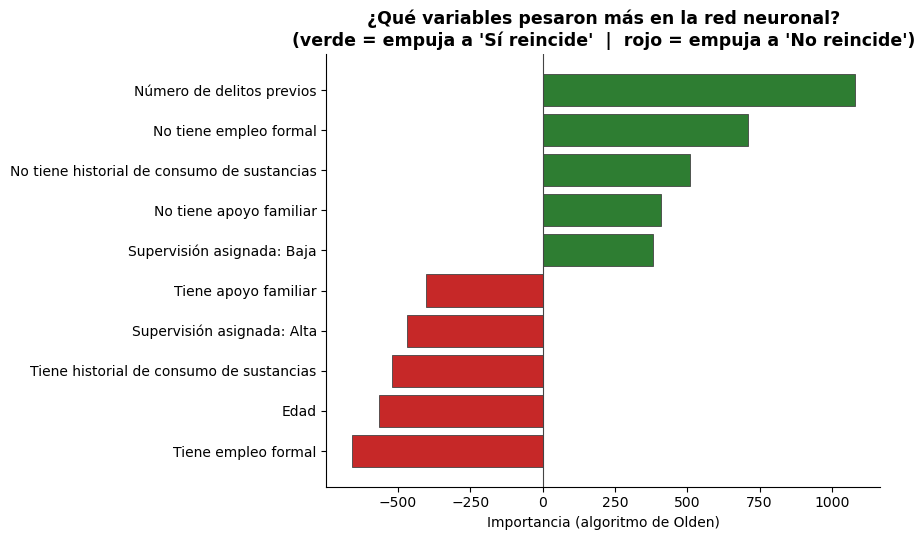

In [14]:
NOMBRES_LEGIBLES = {
    "consumo_sustancias_No": "Tiene historial de consumo de sustancias",
    "consumo_sustancias_Si": "No tiene historial de consumo de sustancias",
    "empleo_No": "No tiene empleo formal",
    "empleo_Si": "Tiene empleo formal",
    "supervision_post_Alta": "Supervisión asignada: Alta",
    "supervision_post_Baja": "Supervisión asignada: Baja",
    "num_delitos_previos": "Número de delitos previos",
    "apoyo_familiar_Si": "Tiene apoyo familiar",
    "apoyo_familiar_No": "No tiene apoyo familiar",
    "edad": "Edad",
}

top10 = serie_olden_ordenada.head(10).sort_values()  # ascendente para barh
etiquetas_top10 = [NOMBRES_LEGIBLES.get(v, v.replace("_", " ")) for v in top10.index]
colores_top10 = ["#2E7D32" if v > 0 else "#C62828" for v in top10.values]

fig, ax = plt.subplots(figsize=(9, 5.5))
barras = ax.barh(etiquetas_top10, top10.values, color=colores_top10, edgecolor="#444444", linewidth=0.6)
ax.axvline(0, color="#444444", linewidth=0.8)
ax.set_xlabel("Importancia (algoritmo de Olden)")
ax.set_title("¿Qué variables pesaron más en la red neuronal?\n(verde = empuja a 'Sí reincide'  |  rojo = empuja a 'No reincide')",
              fontsize=12.5, fontweight="bold")
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## PASO 9. Visualizar la arquitectura de la red

Dibujamos cada neurona como un círculo y cada conexión como una línea:
- **verde** = peso positivo, **rojo** = peso negativo
- líneas más intensas = pesos más fuertes (mayor influencia)

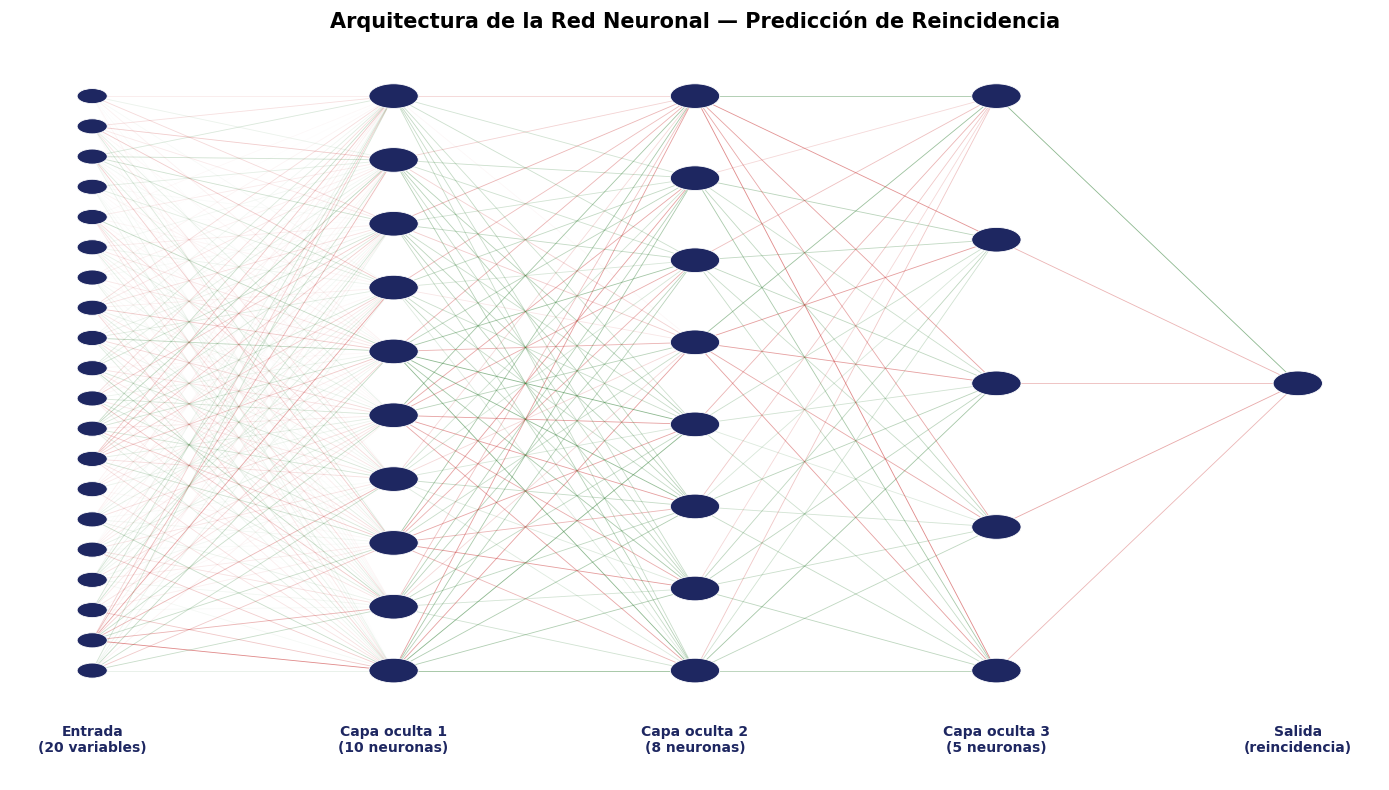

In [15]:
layer_sizes = [X_train.shape[1]] + list(modelo_red.hidden_layer_sizes) + [1]

fig, ax = plt.subplots(figsize=(14, 8))
n_layers = len(layer_sizes)
layer_x = np.linspace(0.06, 0.94, n_layers)

# Calculamos la posición (x, y) de cada neurona, capa por capa
posiciones = []
for li, n in enumerate(layer_sizes):
    ys = np.linspace(0.08, 0.92, n) if n > 1 else [0.5]
    posiciones.append([(layer_x[li], y) for y in ys])

# Dibujar las conexiones (líneas) entre capas consecutivas
for li in range(n_layers - 1):
    pesos = modelo_red.coefs_[li]
    peso_max_abs = np.abs(pesos).max()
    for i, (x0, y0) in enumerate(posiciones[li]):
        for j, (x1, y1) in enumerate(posiciones[li + 1]):
            peso = pesos[i, j]
            transparencia = min(abs(peso) / peso_max_abs, 1.0) * 0.55
            color_linea = "#2E7D32" if peso > 0 else "#C62828"
            ax.plot([x0, x1], [y0, y1], color=color_linea, alpha=transparencia,
                     linewidth=0.6, zorder=1)

# Dibujar las neuronas (círculos) encima de las líneas
etiquetas_capas = ["Entrada\n(20 variables)", "Capa oculta 1\n(10 neuronas)",
                    "Capa oculta 2\n(8 neuronas)", "Capa oculta 3\n(5 neuronas)",
                    "Salida\n(reincidencia)"]
for li, capa in enumerate(posiciones):
    radio = 0.011 if layer_sizes[li] > 12 else 0.018
    for (x, y) in capa:
        ax.add_patch(Circle((x, y), radio, facecolor="#1E2761", edgecolor="white",
                             linewidth=0.6, zorder=2))
    ax.text(layer_x[li], 0.0, etiquetas_capas[li], ha="center", va="top",
             fontsize=10, fontweight="bold", color="#1E2761")

ax.set_xlim(0, 1)
ax.set_ylim(-0.08, 1)
ax.axis("off")
ax.set_title("Arquitectura de la Red Neuronal — Predicción de Reincidencia",
              fontsize=15, fontweight="bold", pad=10)
plt.tight_layout()
plt.show()

**LECTURA PARA ENTENDER:**
- Las líneas más oscuras representan los pesos más influyentes en la red.
- A diferencia del árbol (que puedes "leer" nodo por nodo) o de Naive Bayes (que puedes leer como probabilidades), una red neuronal con varias capas es mucho más difícil de interpretar de forma directa — por eso recurrimos a este tipo de gráficos para entender, al menos, el efecto NETO de cada variable de entrada.

## PASO 10. Aplicar el modelo a registros nuevos (sin etiqueta conocida)

**Nota:** ajusta también la ruta de este segundo CSV a donde tengas guardado el archivo de registros nuevos.

In [17]:
nuevos = pd.read_csv(r"datos\nuevos_registros_reincidencia.csv")
nuevos

,edad,delito_previo,num_delitos_previos,meses_en_prision,empleo,apoyo_familiar,consumo_sustancias,nivel_educativo,supervision_post
0,19,Robo,2,36,Si,No,Si,Preparatoria,Media
1,53,Robo,1,15,No,No,No,Universidad,Alta
2,58,Fraude,1,16,Si,No,Si,Preparatoria,Media
3,27,Robo,2,15,No,No,No,Preparatoria,Media
4,58,Violencia_familiar,1,38,Si,Si,No,Primaria,Baja
5,36,Violencia_familiar,1,27,No,Si,No,Primaria,Media
6,22,Robo,0,43,No,Si,No,Primaria,Media
7,23,Narcomenudeo,0,12,Si,Si,Si,Primaria,Baja
8,19,Fraude,1,53,No,Si,No,Secundaria,Media
9,41,Robo,1,43,Si,Si,No,Primaria,Baja


In [18]:
nuevos_dummies = pd.get_dummies(
    nuevos,
    columns=["delito_previo", "empleo", "apoyo_familiar",
             "consumo_sustancias", "nivel_educativo", "supervision_post"])

# Mismo paso crítico que en Random Forest: alinear columnas con reindex()
nuevos_dummies = nuevos_dummies.reindex(columns=X.columns, fill_value=0)

# IMPORTANTE: usamos el MISMO scaler que ajustamos en el Paso 4 (ya
# entrenado con X_train) — nunca volvemos a hacer fit() sobre datos nuevos.
nuevos_escalados = scaler.transform(nuevos_dummies)

predicciones_nuevas = modelo_red.predict(nuevos_escalados)
probabilidades_nuevas = modelo_red.predict_proba(nuevos_escalados)[:, 1]

In [19]:
resultados = nuevos.copy()
resultados["prediccion_reincidencia"] = le_objetivo.inverse_transform(predicciones_nuevas)
resultados["probabilidad_reincidencia"] = probabilidades_nuevas.round(3)
resultados = resultados.sort_values("probabilidad_reincidencia", ascending=False)

print("\n" + "="*70)
print("PREDICCIONES DE LA RED NEURONAL PARA LOS NUEVOS REGISTROS")
print("="*70)
print(resultados[["edad", "delito_previo", "empleo", "consumo_sustancias",
                   "num_delitos_previos", "probabilidad_reincidencia"]].to_string(index=False))


PREDICCIONES DE LA RED NEURONAL PARA LOS NUEVOS REGISTROS
 edad      delito_previo empleo consumo_sustancias  num_delitos_previos  probabilidad_reincidencia
   19               Robo     Si                 Si                    2                      0.961
   27               Robo     No                 No                    2                      0.955
   36 Violencia_familiar     No                 No                    1                      0.019
   23       Narcomenudeo     Si                 Si                    0                      0.013
   53               Robo     No                 No                    1                      0.010
   58             Fraude     Si                 Si                    1                      0.010
   58 Violencia_familiar     Si                 No                    1                      0.010
   22               Robo     No                 No                    0                      0.010
   19             Fraude     No                 No